### Vocoder Comparison Framework for Speech Synthesis

Title:
HiFi-GAN vs VITS Vocoder Performance Comparison

Short Description:
This code demonstrates a comparative analysis between two state-of-the-art vocoders: HiFi-GAN and VITS. It generates speech from text using a shared mel-spectrogram representation, converts it to audio using both vocoders, and provides real-time playback for qualitative comparison.

Key Libraries Used:

    transformers: SpeechT5 for text-to-mel generation, HiFi-GAN and VITS vocoders

    soundfile: Audio file saving

    sounddevice: Real-time audio playback

    torch: Model inference and tensor operations

Code Logic and Flow

High-Level Overview:
The framework first generates a mel-spectrogram from text using SpeechT5. This shared acoustic representation is then converted to waveform audio using two different vocoders (HiFi-GAN and VITS). The outputs are played instantly for comparison and saved as WAV files for further analysis.

Visual FlowChart:

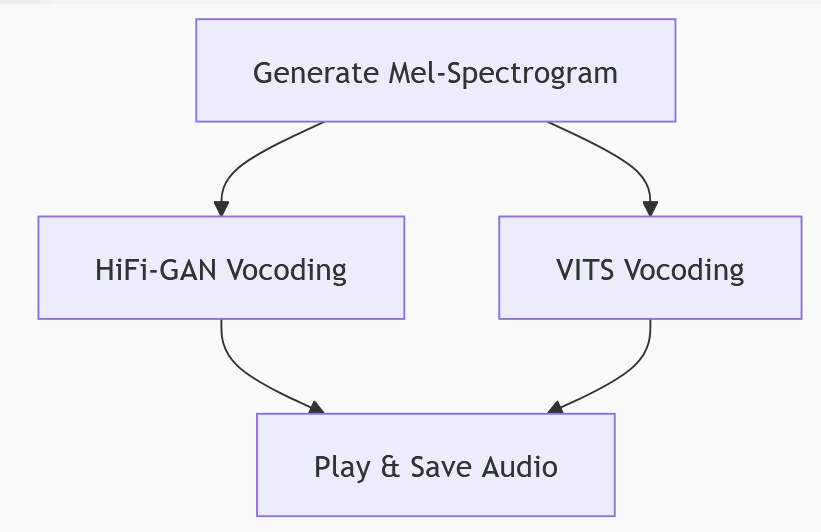

Step-by-Step Code Breakdown

Step 1: Environment Setup

    Loads Hugging Face API token from .env file

    Ensures secure access to protected models

Step 2: Text-to-Mel Conversion

    Initializes SpeechT5 text-to-speech model

    Processes input text into token IDs

    Generates mel-spectrogram using random speaker embeddings

    Creates shared acoustic representation for fair comparison

Step 3: Vocoder Comparison

    HiFi-GAN Pathway:

        Loads specialized HiFi-GAN vocoder

        Converts mel-spectrogram to waveform

        Plays audio instantly through sounddevice

        Saves output as WAV file

    VITS Pathway:

        Initializes VITS end-to-end TTS model

        Processes text directly to waveform

        Plays and saves comparative output

        Maintains original sampling rate

Step 4: Audio Output

    Provides immediate playback for qualitative assessment

    Generates labeled WAV files:

        output_hifigan.wav

        output_yourtts.wav

    Returns waveform tensors for further processing

Connecting to the Lecture**

    Vocoder Technology: Compares different waveform generation approaches

    Acoustic Representation: Uses shared mel-spectrogram for controlled comparison

    Real-Time Evaluation: Enables immediate perceptual quality assessment

    Model Specialization: HiFi-GAN as dedicated vocoder vs VITS as end-to-end system

    Reproducible Testing: Saves outputs for offline analysis

    Hugging Face Ecosystem: Demonstrates model interoperability

    Security Practices: Uses .env for credential management

    Quality Metrics: Facilitates both subjective (listening) and objective (file analysis) evaluation

    Text-to-Speech Pipeline: Illustrates complete TTS workflow from text to audio

    Research Application: Provides template for vocoder performance benchmarking

In [2]:
#good
from dotenv import load_dotenv
import os

load_dotenv()
hf_token = os.getenv("HF_TOKEN")

from transformers import SpeechT5Processor, SpeechT5ForTextToSpeech, SpeechT5HifiGan
from transformers import VitsModel, AutoTokenizer
import torch
import soundfile as sf
import sounddevice as sd

# Generate shared mel-spectrogram using SpeechT5
processor = SpeechT5Processor.from_pretrained("microsoft/speecht5_tts")
model = SpeechT5ForTextToSpeech.from_pretrained(
    "microsoft/speecht5_tts", 
    use_safetensors=True
)

inputs = processor(text="Hello, this is a vocoder comparison test", return_tensors="pt")
speaker_embeddings = torch.randn((1, 512))  
input_ids = inputs["input_ids"]  

mel_spectrogram = model.generate_speech(
    input_ids, 
    speaker_embeddings
)

def compare_vocoders(mel, output_prefix="output"):
    hifigan = SpeechT5HifiGan.from_pretrained(
        "microsoft/speecht5_hifigan", 
        use_safetensors=True
    )
    waveform_hifigan = hifigan(mel)
    print("Playing HiFi-GAN output...")
    sd.play(waveform_hifigan.detach().numpy().squeeze(), 16000)
    sd.wait()
    sf.write(f"{output_prefix}_hifigan.wav", waveform_hifigan.detach().numpy().squeeze(), 16000)
    
    # Use VitsModel for text-to-speech synthesis
    yourtts = VitsModel.from_pretrained("facebook/mms-tts-eng")
    tokenizer = AutoTokenizer.from_pretrained("facebook/mms-tts-eng")
    inputs = tokenizer("Hello, this is a test", return_tensors="pt")
    outputs = yourtts(**inputs)
    waveform_yourtts = outputs.waveform
    print("Playing Vits output...")
    sd.play(waveform_yourtts.detach().numpy().squeeze(), yourtts.config.sampling_rate)
    sd.wait()
    sf.write(f"{output_prefix}_yourtts.wav", waveform_yourtts.detach().numpy().squeeze(), yourtts.config.sampling_rate)
    
    return waveform_hifigan, waveform_yourtts

hifigan_wav, yourtts_wav = compare_vocoders(mel_spectrogram)

Playing HiFi-GAN output...
Playing Vits output...
